In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')

In [53]:
df=pd.read_csv(r"C:\Users\zinan\OneDrive\Desktop\Documents\Python\kerala_smart_meter_v6.csv")
df

,Meter_ID,Dwelling_Type,Num_Occupants,House_Area_sqft,Connected_Load_kW,Meter_Age_Years,Date,Temperature_C,Humidity_pct,Grid_Outage_Hours,Appliance_Score,Anomaly_Type,Meter_Bypass_Signal,Has_Solar_Panel,Voltage_V,Power_Factor,Expected_Energy_kWh,Actual_Energy_kWh,Peak_Hour_Usage_kWh,Off_Peak_Usage_kWh
0,IN-KL-ELC-80473566,Apartment,8,3111,12.96,8,28-12-2023,24.37,64.36,0.00,21.0,4,0,0,224.96,0.71,33.07 kWh,191.55 kWh,119.04 kWh,56.66 kWh
1,IN-KL-ELC-16501416,Apartment,3,2802,8.32,8,21-11-2022,26.61,58.80,0.00,4.0,2,0,1,236.14,0.81,42.17 kWh,71.57 kWh,43.74 kWh,17.43 kWh
2,IN-KL-ELC-36276199,Apartment,2,3172,9.06,9,03-07-2022,28.74,82.52,7.55,5.0,1,1,0,220.05,0.75,38.09 kWh,116.42 kWh,67.71 kWh,42.05 kWh
3,IN-KL-ELC-75536400,Villa,5,3637,10.52,12,21-11-2023,26.14,68.06,0.00,9.0,2,0,1,217.85,0.84,18.21 kWh,36.47 kWh,20.69 kWh,8.73 kWh
4,IN-KL-ELC-34191368,Apartment,7,3184,12.93,17,21-07-2023,24.30,79.41,0.00,3.0,4,0,0,216.08,0.69,33.49 kWh,117.60 kWh,62.14 kWh,37.86 kWh
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10030,IN-KL-ELC-83353025,Commercial,8,1298,3.73,15,23-09-2022,28.96,77.38,0.00,21.0,1,0,0,231.62,0.72,37.03 kWh,45.15 kWh,24.41 kWh,14.86 kWh
10031,IN-KL-ELC-55916461,Villa,4,3132,11.07,1,08-09-2023,31.11,78.69,4.51,7.0,1,0,0,216.93,0.72,10.28 kWh,130.14 kWh,71.59 kWh,44.74 kWh
10032,IN-KL-ELC-09906171,Commercial,5,1691,2.86,5,15-08-2022,25.12,91.53,4.07,11.0,1,1,1,216.65,0.79,7.38 kWh,24.56 kWh,14.07 kWh,7.34 kWh
10033,IN-KL-ELC-92924887,Villa,6,4790,15.00,11,19-05-2023,36.71,76.17,0.00,7.0,0,0,0,225.41,0.80,12.80 kWh,27.78 kWh,14.49 kWh,9.00 kWh


In [54]:
df.shape

(10035, 20)

In [55]:
df.head()

,Meter_ID,Dwelling_Type,Num_Occupants,House_Area_sqft,Connected_Load_kW,Meter_Age_Years,Date,Temperature_C,Humidity_pct,Grid_Outage_Hours,Appliance_Score,Anomaly_Type,Meter_Bypass_Signal,Has_Solar_Panel,Voltage_V,Power_Factor,Expected_Energy_kWh,Actual_Energy_kWh,Peak_Hour_Usage_kWh,Off_Peak_Usage_kWh
0,IN-KL-ELC-80473566,Apartment,8,3111,12.96,8,28-12-2023,24.37,64.36,0.00,21.0,4,0,0,224.96,0.71,33.07 kWh,191.55 kWh,119.04 kWh,56.66 kWh
1,IN-KL-ELC-16501416,Apartment,3,2802,8.32,8,21-11-2022,26.61,58.80,0.00,4.0,2,0,1,236.14,0.81,42.17 kWh,71.57 kWh,43.74 kWh,17.43 kWh
2,IN-KL-ELC-36276199,Apartment,2,3172,9.06,9,03-07-2022,28.74,82.52,7.55,5.0,1,1,0,220.05,0.75,38.09 kWh,116.42 kWh,67.71 kWh,42.05 kWh
3,IN-KL-ELC-75536400,Villa,5,3637,10.52,12,21-11-2023,26.14,68.06,0.00,9.0,2,0,1,217.85,0.84,18.21 kWh,36.47 kWh,20.69 kWh,8.73 kWh
4,IN-KL-ELC-34191368,Apartment,7,3184,12.93,17,21-07-2023,24.30,79.41,0.00,3.0,4,0,0,216.08,0.69,33.49 kWh,117.60 kWh,62.14 kWh,37.86 kWh


In [56]:
df.tail()

,Meter_ID,Dwelling_Type,Num_Occupants,House_Area_sqft,Connected_Load_kW,Meter_Age_Years,Date,Temperature_C,Humidity_pct,Grid_Outage_Hours,Appliance_Score,Anomaly_Type,Meter_Bypass_Signal,Has_Solar_Panel,Voltage_V,Power_Factor,Expected_Energy_kWh,Actual_Energy_kWh,Peak_Hour_Usage_kWh,Off_Peak_Usage_kWh
10030,IN-KL-ELC-83353025,Commercial,8,1298,3.73,15,23-09-2022,28.96,77.38,0.00,21.0,1,0,0,231.62,0.72,37.03 kWh,45.15 kWh,24.41 kWh,14.86 kWh
10031,IN-KL-ELC-55916461,Villa,4,3132,11.07,1,08-09-2023,31.11,78.69,4.51,7.0,1,0,0,216.93,0.72,10.28 kWh,130.14 kWh,71.59 kWh,44.74 kWh
10032,IN-KL-ELC-09906171,Commercial,5,1691,2.86,5,15-08-2022,25.12,91.53,4.07,11.0,1,1,1,216.65,0.79,7.38 kWh,24.56 kWh,14.07 kWh,7.34 kWh
10033,IN-KL-ELC-92924887,Villa,6,4790,15.00,11,19-05-2023,36.71,76.17,0.00,7.0,0,0,0,225.41,0.80,12.80 kWh,27.78 kWh,14.49 kWh,9.00 kWh
10034,IN-KL-ELC-02769036,Commercial,5,726,1.83,16,06-11-2023,26.20,64.05,5.01,11.0,2,0,0,208.77,0.85,38.39 kWh,68.40 kWh,39.57 kWh,20.23 kWh


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10035 entries, 0 to 10034
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Meter_ID             10035 non-null  object 
 1   Dwelling_Type        10035 non-null  object 
 2   Num_Occupants        10035 non-null  int64  
 3   House_Area_sqft      10035 non-null  int64  
 4   Connected_Load_kW    10035 non-null  float64
 5   Meter_Age_Years      10035 non-null  int64  
 6   Date                 10035 non-null  object 
 7   Temperature_C        10020 non-null  float64
 8   Humidity_pct         10019 non-null  float64
 9   Grid_Outage_Hours    10035 non-null  float64
 10  Appliance_Score      10025 non-null  float64
 11  Anomaly_Type         10035 non-null  int64  
 12  Meter_Bypass_Signal  10035 non-null  int64  
 13  Has_Solar_Panel      10035 non-null  int64  
 14  Voltage_V            10035 non-null  float64
 15  Power_Factor         10025 non-null 

In [58]:
df.describe()

,Num_Occupants,House_Area_sqft,Connected_Load_kW,Meter_Age_Years,Temperature_C,Humidity_pct,Grid_Outage_Hours,Appliance_Score,Anomaly_Type,Meter_Bypass_Signal,Has_Solar_Panel,Voltage_V,Power_Factor
count,10035.000000,10035.000000,10035.000000,10035.00000,10020.000000,10019.000000,10035.000000,10025.000000,10035.000000,10035.000000,10035.000000,10035.000000,10025.000000
mean,4.521574,2689.890882,8.524702,10.42870,28.474271,69.160129,1.444821,12.920000,1.310214,0.203986,0.386049,228.746808,0.813321
std,2.299268,1326.366130,3.947018,5.26429,3.767915,13.712313,2.389122,7.200358,1.331504,0.402979,0.486866,7.735146,0.082484
min,1.000000,400.000000,1.500000,1.00000,22.000000,45.000000,0.000000,1.000000,0.000000,0.000000,0.000000,195.000000,0.650000
25%,2.000000,1536.000000,5.190000,6.00000,25.557500,58.180000,0.000000,7.000000,0.000000,0.000000,0.000000,224.210000,0.750000
50%,5.000000,2705.000000,8.750000,11.00000,28.215000,67.620000,0.000000,13.000000,1.000000,0.000000,0.000000,228.860000,0.810000
75%,7.000000,3838.500000,11.810000,15.00000,30.570000,80.225000,2.415000,19.000000,2.000000,0.000000,1.000000,233.335000,0.870000
max,8.000000,5000.000000,15.000000,19.00000,38.000000,95.000000,8.000000,25.000000,4.000000,1.000000,1.000000,260.000000,0.990000


In [59]:
df.describe(include='O')

,Meter_ID,Dwelling_Type,Date,Expected_Energy_kWh,Actual_Energy_kWh,Peak_Hour_Usage_kWh,Off_Peak_Usage_kWh
count,10035,10035,10035,9782,9900,10035,10035
unique,10000,4,730,5411,6729,6060,4512
top,IN-KL-ELC-05752810,Commercial,08-01-2023,38.92 kWh,100.00 kWh,0.0 kWh,0.49 kWh
freq,2,2558,28,9,353,12,13


In [60]:
df.duplicated().sum()

np.int64(35)

In [61]:
df.drop_duplicates(inplace=True)

In [62]:
df.duplicated().sum()

np.int64(0)

In [63]:
df.isna().sum()

Meter_ID                 0
Dwelling_Type            0
Num_Occupants            0
House_Area_sqft          0
Connected_Load_kW        0
Meter_Age_Years          0
Date                     0
Temperature_C           15
Humidity_pct            15
Grid_Outage_Hours        0
Appliance_Score         10
Anomaly_Type             0
Meter_Bypass_Signal      0
Has_Solar_Panel          0
Voltage_V                0
Power_Factor            10
Expected_Energy_kWh    253
Actual_Energy_kWh      135
Peak_Hour_Usage_kWh      0
Off_Peak_Usage_kWh       0
dtype: int64

In [64]:
df.dtypes

Meter_ID                object
Dwelling_Type           object
Num_Occupants            int64
House_Area_sqft          int64
Connected_Load_kW      float64
Meter_Age_Years          int64
Date                    object
Temperature_C          float64
Humidity_pct           float64
Grid_Outage_Hours      float64
Appliance_Score        float64
Anomaly_Type             int64
Meter_Bypass_Signal      int64
Has_Solar_Panel          int64
Voltage_V              float64
Power_Factor           float64
Expected_Energy_kWh     object
Actual_Energy_kWh       object
Peak_Hour_Usage_kWh     object
Off_Peak_Usage_kWh      object
dtype: object

In [65]:
df1=df['Anomaly_Type'].value_counts()
df1

Anomaly_Type
0    3800
1    2400
2    1600
3    1300
4     900
Name: count, dtype: int64

Text(0.5, 1.0, 'Anomoly_Type_Chart')

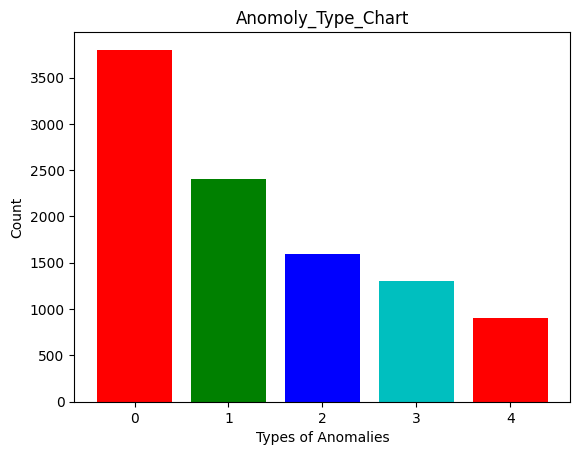

In [66]:
plt.bar(df1.index,df1.values,color=['r','g','b','c'])
plt.xlabel('Types of Anomalies')
plt.ylabel('Count')
plt.title('Anomoly_Type_Chart')

In [67]:
df['Expected_Energy_kWh']=df['Expected_Energy_kWh'].str.replace("kWh"," ",regex=False)
df["Actual_Energy_kWh"]=df["Actual_Energy_kWh"].str.replace("kWh"," ",regex=False)
df["Peak_Hour_Usage_kWh"]=df["Peak_Hour_Usage_kWh"].str.replace("kWh"," ",regex=False)
df["Off_Peak_Usage_kWh"]=df["Off_Peak_Usage_kWh"].str.replace("kWh"," ",regex=False)

In [68]:
df.dtypes

Meter_ID                object
Dwelling_Type           object
Num_Occupants            int64
House_Area_sqft          int64
Connected_Load_kW      float64
Meter_Age_Years          int64
Date                    object
Temperature_C          float64
Humidity_pct           float64
Grid_Outage_Hours      float64
Appliance_Score        float64
Anomaly_Type             int64
Meter_Bypass_Signal      int64
Has_Solar_Panel          int64
Voltage_V              float64
Power_Factor           float64
Expected_Energy_kWh     object
Actual_Energy_kWh       object
Peak_Hour_Usage_kWh     object
Off_Peak_Usage_kWh      object
dtype: object

In [69]:
df['Expected_Energy_kWh']=df['Expected_Energy_kWh'].str.replace("null","0",regex=False)
df["Actual_Energy_kWh"]=df["Actual_Energy_kWh"].str.replace("null","0",regex=False)
df["Peak_Hour_Usage_kWh"]=df["Peak_Hour_Usage_kWh"].str.replace("null","0",regex=False)
df["Off_Peak_Usage_kWh"]=df["Off_Peak_Usage_kWh"].str.replace("null","0",regex=False)

In [70]:
df['Expected_Energy_kWh']=df['Expected_Energy_kWh'].astype(float)
df["Actual_Energy_kWh"]=df["Actual_Energy_kWh"].astype(float)
df["Peak_Hour_Usage_kWh"]=df["Peak_Hour_Usage_kWh"].astype(float)
df["Off_Peak_Usage_kWh"]=df["Off_Peak_Usage_kWh"].astype(float)

In [71]:
df.loc[df['Expected_Energy_kWh']<=0,'Expected_Energy_kWh']=np.nan
df.loc[df['Actual_Energy_kWh']==0,'Actual_Energy_kWh']=np.nan
df.loc[df['Peak_Hour_Usage_kWh']==0,'Peak_Hour_Usage_kWh']=np.nan
df.loc[df['Off_Peak_Usage_kWh']==0,'Off_Peak_Usage_kWh']=np.nan

In [72]:
df.dtypes

Meter_ID                object
Dwelling_Type           object
Num_Occupants            int64
House_Area_sqft          int64
Connected_Load_kW      float64
Meter_Age_Years          int64
Date                    object
Temperature_C          float64
Humidity_pct           float64
Grid_Outage_Hours      float64
Appliance_Score        float64
Anomaly_Type             int64
Meter_Bypass_Signal      int64
Has_Solar_Panel          int64
Voltage_V              float64
Power_Factor           float64
Expected_Energy_kWh    float64
Actual_Energy_kWh      float64
Peak_Hour_Usage_kWh    float64
Off_Peak_Usage_kWh     float64
dtype: object

In [73]:
df.isna().sum()

Meter_ID                  0
Dwelling_Type             0
Num_Occupants             0
House_Area_sqft           0
Connected_Load_kW         0
Meter_Age_Years           0
Date                      0
Temperature_C            15
Humidity_pct             15
Grid_Outage_Hours         0
Appliance_Score          10
Anomaly_Type              0
Meter_Bypass_Signal       0
Has_Solar_Panel           0
Voltage_V                 0
Power_Factor             10
Expected_Energy_kWh    1744
Actual_Energy_kWh       135
Peak_Hour_Usage_kWh      12
Off_Peak_Usage_kWh        8
dtype: int64

In [74]:
df['Temperature_C'].unique()

array([24.37, 26.61, 28.74, ..., 34.85, 34.64, 34.73], shape=(1557,))

In [75]:
df['Humidity_pct'].unique()

array([64.36, 58.8 , 82.52, ..., 62.43, 87.36, 87.41], shape=(4206,))

In [76]:
df['Power_Factor'].unique()

array([0.71, 0.81, 0.75, 0.84, 0.69, 0.92, 0.8 , 0.91, 0.7 , 0.77, 0.9 ,
       0.74, 0.83, 0.73, 0.66, 0.82, 0.87, 0.76, 0.94, 0.96, 0.79, 0.93,
       0.78, 0.89, 0.86, 0.72, 0.68, 0.99, 0.67, 0.65, 0.95, 0.88, 0.85,
       0.97, 0.98,  nan])

In [77]:
df['Appliance_Score'].unique()

array([21.,  4.,  5.,  9.,  3., 13., 17.,  8.,  6., 14., 18., 11., 24.,
       15., 10., 25., 22.,  2.,  1., 23., 19.,  7., 16., 12., 20., nan])

In [78]:
df['Peak_Hour_Usage_kWh'].unique()

array([119.04,  43.74,  67.71, ...,  40.91,  65.22,  32.56], shape=(6060,))

In [79]:
df['Off_Peak_Usage_kWh'].unique()

array([56.66, 17.43, 42.05, ..., 67.01, 25.55,  7.34], shape=(4512,))

In [80]:
df['Temperature_C']=df['Temperature_C'].fillna(df['Temperature_C'].median())
df['Humidity_pct']=df['Humidity_pct'].fillna(df['Humidity_pct'].median())
df['Power_Factor']=df['Power_Factor'].fillna(df['Power_Factor'].mode()[0])
df['Appliance_Score']=df['Appliance_Score'].fillna(df['Appliance_Score'].median())
df['Expected_Energy_kWh']=df['Expected_Energy_kWh'].fillna(df['Expected_Energy_kWh'].median())
df['Actual_Energy_kWh']=df['Actual_Energy_kWh'].fillna(df['Actual_Energy_kWh'].median())
df['Peak_Hour_Usage_kWh']=df['Peak_Hour_Usage_kWh'].fillna(df['Peak_Hour_Usage_kWh'].median())
df['Off_Peak_Usage_kWh']=df['Off_Peak_Usage_kWh'].fillna(df['Off_Peak_Usage_kWh'].median())

In [81]:
df.isna().sum()

Meter_ID               0
Dwelling_Type          0
Num_Occupants          0
House_Area_sqft        0
Connected_Load_kW      0
Meter_Age_Years        0
Date                   0
Temperature_C          0
Humidity_pct           0
Grid_Outage_Hours      0
Appliance_Score        0
Anomaly_Type           0
Meter_Bypass_Signal    0
Has_Solar_Panel        0
Voltage_V              0
Power_Factor           0
Expected_Energy_kWh    0
Actual_Energy_kWh      0
Peak_Hour_Usage_kWh    0
Off_Peak_Usage_kWh     0
dtype: int64

In [82]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")
df["Month"] = df["Date"].dt.month
df["Day_of_Week"] = df["Date"].dt.dayofweek

In [83]:
def get_season(month):
    if month in [3,4,5]:
        return "Summer"
    elif month in [6,7,8,9]:
        return "Monsoon"
    else:
        return "Winter"
df["Season"] = df["Month"].apply(get_season)

In [84]:
eps = 1e-5
df["Energy_Deviation_Ratio"] = (df["Actual_Energy_kWh"] - df["Expected_Energy_kWh"]) / (df["Expected_Energy_kWh"] + eps)
df["Energy_Per_Occupant"]    = df["Actual_Energy_kWh"] / (df["Num_Occupants"] + eps)
df["Peak_To_Total_Ratio"]    = df["Peak_Hour_Usage_kWh"] / (df["Actual_Energy_kWh"] + eps)
df["Load_Utilization_pct"]   = df["Actual_Energy_kWh"] / (df["Connected_Load_kW"] * 24 + eps)
df["Energy_Per_Sqft"]        = df["Actual_Energy_kWh"] / (df["House_Area_sqft"] + eps)

In [85]:
df["Anomaly_Risk_Score"] = (
    df["Meter_Bypass_Signal"] * 3 +
    (df["Grid_Outage_Hours"] > 0).astype(int) +
    (df["Energy_Deviation_Ratio"] > 1).astype(int)
)

In [86]:
df.dtypes

Meter_ID                          object
Dwelling_Type                     object
Num_Occupants                      int64
House_Area_sqft                    int64
Connected_Load_kW                float64
Meter_Age_Years                    int64
Date                      datetime64[ns]
Temperature_C                    float64
Humidity_pct                     float64
Grid_Outage_Hours                float64
Appliance_Score                  float64
Anomaly_Type                       int64
Meter_Bypass_Signal                int64
Has_Solar_Panel                    int64
Voltage_V                        float64
Power_Factor                     float64
Expected_Energy_kWh              float64
Actual_Energy_kWh                float64
Peak_Hour_Usage_kWh              float64
Off_Peak_Usage_kWh               float64
Month                              int32
Day_of_Week                        int32
Season                            object
Energy_Deviation_Ratio           float64
Energy_Per_Occup

In [87]:
df.drop(['Meter_ID','Date'],axis=1,inplace=True)
df.dtypes

Dwelling_Type              object
Num_Occupants               int64
House_Area_sqft             int64
Connected_Load_kW         float64
Meter_Age_Years             int64
Temperature_C             float64
Humidity_pct              float64
Grid_Outage_Hours         float64
Appliance_Score           float64
Anomaly_Type                int64
Meter_Bypass_Signal         int64
Has_Solar_Panel             int64
Voltage_V                 float64
Power_Factor              float64
Expected_Energy_kWh       float64
Actual_Energy_kWh         float64
Peak_Hour_Usage_kWh       float64
Off_Peak_Usage_kWh        float64
Month                       int32
Day_of_Week                 int32
Season                     object
Energy_Deviation_Ratio    float64
Energy_Per_Occupant       float64
Peak_To_Total_Ratio       float64
Load_Utilization_pct      float64
Energy_Per_Sqft           float64
Anomaly_Risk_Score          int64
dtype: object

In [88]:
encoder=LabelEncoder()
df['Dwelling_Type']=encoder.fit_transform(df['Dwelling_Type'])
df['Season']=encoder.fit_transform(df['Season'])

In [89]:
df.dtypes

Dwelling_Type               int64
Num_Occupants               int64
House_Area_sqft             int64
Connected_Load_kW         float64
Meter_Age_Years             int64
Temperature_C             float64
Humidity_pct              float64
Grid_Outage_Hours         float64
Appliance_Score           float64
Anomaly_Type                int64
Meter_Bypass_Signal         int64
Has_Solar_Panel             int64
Voltage_V                 float64
Power_Factor              float64
Expected_Energy_kWh       float64
Actual_Energy_kWh         float64
Peak_Hour_Usage_kWh       float64
Off_Peak_Usage_kWh        float64
Month                       int32
Day_of_Week                 int32
Season                      int64
Energy_Deviation_Ratio    float64
Energy_Per_Occupant       float64
Peak_To_Total_Ratio       float64
Load_Utilization_pct      float64
Energy_Per_Sqft           float64
Anomaly_Risk_Score          int64
dtype: object

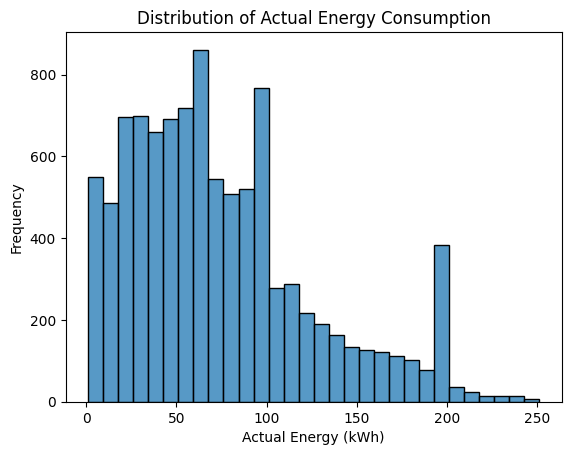

In [90]:
sns.histplot(df["Actual_Energy_kWh"],bins=30)
plt.title("Distribution of Actual Energy Consumption")
plt.xlabel("Actual Energy (kWh)")
plt.ylabel("Frequency")
plt.show()

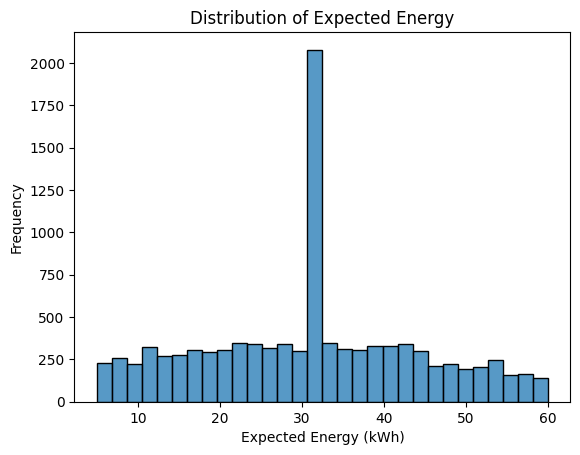

In [91]:
sns.histplot(df["Expected_Energy_kWh"], bins=30)
plt.title("Distribution of Expected Energy")
plt.xlabel("Expected Energy (kWh)")
plt.ylabel("Frequency")
plt.show()

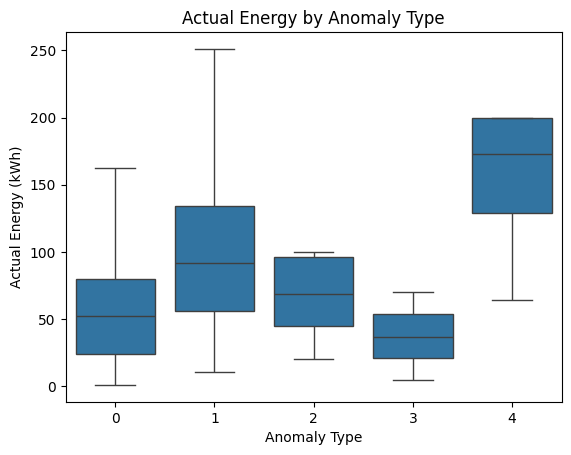

In [92]:
sns.boxplot(x="Anomaly_Type", y="Actual_Energy_kWh", data=df,showfliers=False)
plt.title("Actual Energy by Anomaly Type")
plt.xlabel("Anomaly Type")
plt.ylabel("Actual Energy (kWh)")
plt.show()

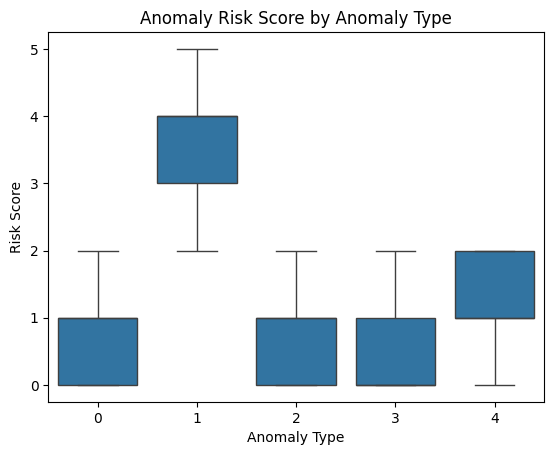

In [93]:
sns.boxplot(x="Anomaly_Type", y="Anomaly_Risk_Score",data=df,showfliers=False)
plt.title("Anomaly Risk Score by Anomaly Type")
plt.xlabel("Anomaly Type")
plt.ylabel("Risk Score")
plt.show()

In [94]:
x=df.drop(["Anomaly_Type"],axis=1)
y=df['Anomaly_Type']

In [95]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42,stratify=y)
x_train

,Dwelling_Type,Num_Occupants,House_Area_sqft,Connected_Load_kW,Meter_Age_Years,Temperature_C,Humidity_pct,Grid_Outage_Hours,Appliance_Score,Meter_Bypass_Signal,...,Off_Peak_Usage_kWh,Month,Day_of_Week,Season,Energy_Deviation_Ratio,Energy_Per_Occupant,Peak_To_Total_Ratio,Load_Utilization_pct,Energy_Per_Sqft,Anomaly_Risk_Score
3966,1,2,579,1.50,2,24.69,82.33,0.00,1.0,1,...,5.76,8,4,0,0.028571,10.079950,0.630952,0.560000,0.034819,3
9299,3,7,3544,15.00,14,24.27,50.85,0.00,22.0,0,...,3.47,10,2,2,-0.614846,1.689998,0.550295,0.032861,0.003338,0
4560,3,6,3608,8.46,10,31.00,78.23,0.00,8.0,0,...,14.16,8,1,0,1.363636,8.666652,0.648654,0.256107,0.014412,1
3912,1,6,3709,10.79,1,29.43,49.27,0.00,15.0,0,...,4.84,2,6,2,-0.481686,2.653329,0.513191,0.061477,0.004292,0
2741,0,4,959,5.12,8,25.41,50.54,0.00,12.0,0,...,3.77,12,5,2,0.912849,3.237492,0.568339,0.105387,0.013504,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4077,1,8,3347,11.59,8,27.47,62.37,0.75,2.0,0,...,11.14,11,0,2,1.347529,5.167494,0.622158,0.148619,0.012351,2
9200,1,2,3699,11.67,6,27.08,46.84,0.00,2.0,1,...,39.75,1,0,2,3.486280,76.849616,0.544762,0.548772,0.041552,4
303,2,7,1269,4.67,1,25.91,79.68,2.49,3.0,0,...,13.96,9,6,0,1.063266,7.454275,0.600805,0.465560,0.041119,2
3537,0,4,2057,13.82,14,30.03,83.45,2.36,17.0,0,...,53.32,9,3,0,3.064214,49.999875,0.678100,0.602991,0.097229,2


In [96]:
y_test

8904    0
5320    0
9327    0
7827    0
1605    1
       ..
420     0
7137    2
6072    0
3674    0
6003    0
Name: Anomaly_Type, Length: 2000, dtype: int64

In [97]:
y_train

3966    1
9299    3
4560    2
3912    3
2741    0
       ..
4077    2
9200    1
303     0
3537    4
7102    0
Name: Anomaly_Type, Length: 8000, dtype: int64

In [98]:
y_test

8904    0
5320    0
9327    0
7827    0
1605    1
       ..
420     0
7137    2
6072    0
3674    0
6003    0
Name: Anomaly_Type, Length: 2000, dtype: int64

In [99]:
scaler=StandardScaler()
scaler.fit(x_train)
x_train=scaler.transform(x_train)
x_test=scaler.transform(x_test)

In [100]:
lr = LogisticRegression()
lr.fit(x_train,y_train)
y_pred_lr = lr.predict(x_test)
y_pred_lr

array([0, 0, 2, ..., 0, 3, 0], shape=(2000,))

In [101]:
cm_lr=confusion_matrix(y_test,y_pred_lr)
cm_lr

array([[545,   2,  69, 142,   2],
       [  8, 446,  12,   0,  14],
       [115,   8, 179,  18,   0],
       [ 66,   2,   8, 184,   0],
       [  0,   4,   6,   0, 170]])

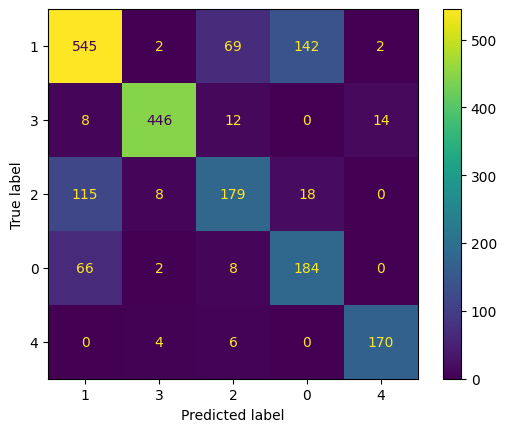

In [102]:
lab=[1,3,2,0,4]
cmd_lr=ConfusionMatrixDisplay(cm_lr,display_labels=lab)
cmd_lr.plot()

In [103]:
score_lr=accuracy_score(y_test,y_pred_lr)*100
score_lr

76.2

In [104]:
report_lr=classification_report(y_test,y_pred_lr)
print(report_lr)

              precision    recall  f1-score   support

           0       0.74      0.72      0.73       760
           1       0.97      0.93      0.95       480
           2       0.65      0.56      0.60       320
           3       0.53      0.71      0.61       260
           4       0.91      0.94      0.93       180

    accuracy                           0.76      2000
   macro avg       0.76      0.77      0.76      2000
weighted avg       0.77      0.76      0.76      2000



In [105]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)
y_pred_knn = knn.predict(x_test)
y_pred_knn

array([3, 3, 2, ..., 0, 0, 0], shape=(2000,))

In [106]:
cm_knn=confusion_matrix(y_test,y_pred_knn)
cm_knn

array([[580,   1,  48, 131,   0],
       [ 21, 434,   8,   2,  15],
       [122,   6, 167,  23,   2],
       [ 73,   0,  12, 175,   0],
       [  5,  10,  13,   0, 152]])

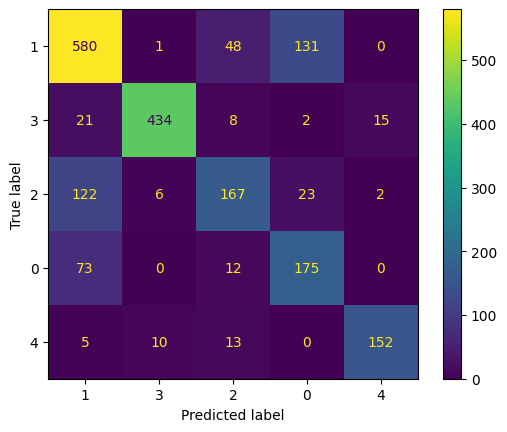

In [107]:
lab=[1,3,2,0,4]
cmd_knn=ConfusionMatrixDisplay(cm_knn,display_labels=lab)
cmd_knn.plot()

In [108]:
score_knn=accuracy_score(y_test,y_pred_knn)*100
score_knn

75.4

In [109]:
report_knn=classification_report(y_test,y_pred_knn)
print(report_knn)

              precision    recall  f1-score   support

           0       0.72      0.76      0.74       760
           1       0.96      0.90      0.93       480
           2       0.67      0.52      0.59       320
           3       0.53      0.67      0.59       260
           4       0.90      0.84      0.87       180

    accuracy                           0.75      2000
   macro avg       0.76      0.74      0.75      2000
weighted avg       0.76      0.75      0.76      2000



In [110]:
nb = GaussianNB()
nb.fit(x_train, y_train)
y_pred_nb = nb.predict(x_test)
y_pred_nb

array([3, 3, 2, ..., 0, 3, 0], shape=(2000,))

In [111]:
cm_nb=confusion_matrix(y_test,y_pred_nb)
cm_nb

array([[351,   0, 161, 232,  16],
       [ 12, 430,  10,   4,  24],
       [ 15,   0, 246,  58,   1],
       [  4,   2,   4, 250,   0],
       [  2,   0,   4,   0, 174]])

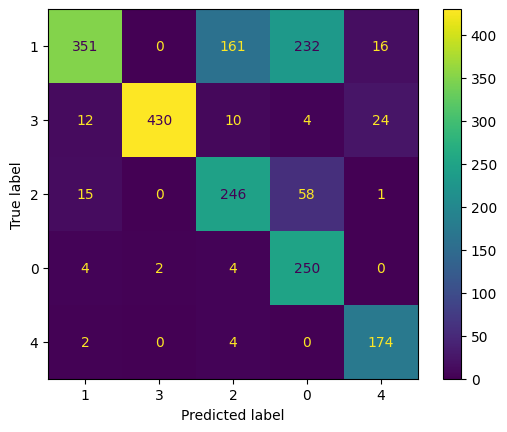

In [112]:
lab=[1,3,2,0,4]
cmd_nb=ConfusionMatrixDisplay(cm_nb,display_labels=lab)
cmd_nb.plot()

In [113]:
score_nb=accuracy_score(y_test,y_pred_nb)*100
score_nb

72.55

In [114]:
report_nb=classification_report(y_test,y_pred_nb)
print(report_nb)

              precision    recall  f1-score   support

           0       0.91      0.46      0.61       760
           1       1.00      0.90      0.94       480
           2       0.58      0.77      0.66       320
           3       0.46      0.96      0.62       260
           4       0.81      0.97      0.88       180

    accuracy                           0.73      2000
   macro avg       0.75      0.81      0.74      2000
weighted avg       0.81      0.73      0.73      2000



In [115]:
svm = SVC(kernel="rbf", random_state=42)
svm.fit(x_train, y_train)
y_pred_svm = svm.predict(x_test)
y_pred_svm

array([0, 3, 2, ..., 0, 0, 0], shape=(2000,))

In [116]:
cm_svm=confusion_matrix(y_test,y_pred_svm)
cm_svm

array([[638,   0,  34,  87,   1],
       [ 13, 439,  10,   1,  17],
       [ 83,   0, 211,  26,   0],
       [ 27,   1,   7, 225,   0],
       [  0,   2,   5,   0, 173]])

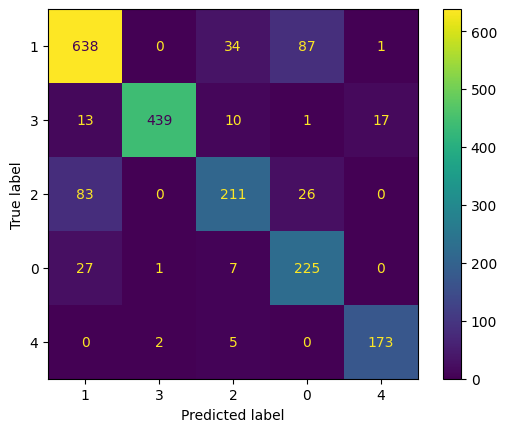

In [117]:
lab=[1,3,2,0,4]
cmd_svm=ConfusionMatrixDisplay(cm_svm,display_labels=lab)
cmd_svm.plot()

In [118]:
score_svm=accuracy_score(y_test,y_pred_svm)*100
score_svm

84.3

In [119]:
report_svm=classification_report(y_test,y_pred_svm)
print(report_svm)

              precision    recall  f1-score   support

           0       0.84      0.84      0.84       760
           1       0.99      0.91      0.95       480
           2       0.79      0.66      0.72       320
           3       0.66      0.87      0.75       260
           4       0.91      0.96      0.93       180

    accuracy                           0.84      2000
   macro avg       0.84      0.85      0.84      2000
weighted avg       0.85      0.84      0.84      2000



In [120]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)
y_pred_dt

array([0, 0, 2, ..., 0, 0, 0], shape=(2000,))

In [121]:
cm_dt=confusion_matrix(y_test,y_pred_dt)
cm_dt

array([[670,  14,  60,  15,   1],
       [ 11, 456,   3,   0,  10],
       [ 61,  12, 238,   6,   3],
       [ 19,   6,   4, 231,   0],
       [  3,   7,   1,   0, 169]])

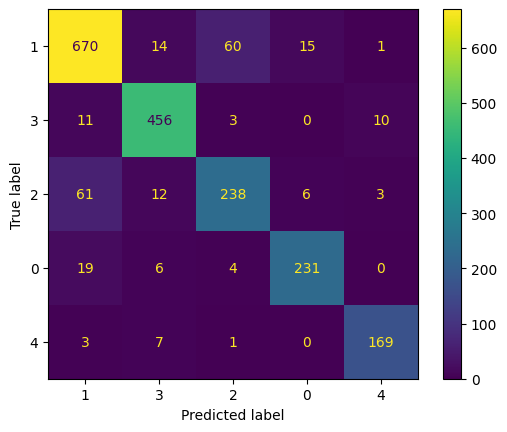

In [122]:
lab=[1,3,2,0,4]
cmd_dt=ConfusionMatrixDisplay(cm_dt,display_labels=lab)
cmd_dt.plot()

In [123]:
score_dt=accuracy_score(y_test,y_pred_dt)*100
score_dt

88.2

In [124]:
report_dt=classification_report(y_test,y_pred_dt)
print(report_dt)

              precision    recall  f1-score   support

           0       0.88      0.88      0.88       760
           1       0.92      0.95      0.94       480
           2       0.78      0.74      0.76       320
           3       0.92      0.89      0.90       260
           4       0.92      0.94      0.93       180

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000



In [125]:
rf = RandomForestClassifier(n_estimators=200,random_state=42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
y_pred_rf

array([0, 0, 2, ..., 0, 0, 0], shape=(2000,))

In [126]:
cm_rf=confusion_matrix(y_test,y_pred_rf)
cm_rf

array([[727,   0,  24,   7,   2],
       [ 13, 452,   3,   0,  12],
       [ 61,   1, 256,   1,   1],
       [ 17,   1,   5, 237,   0],
       [  0,   0,   0,   0, 180]])

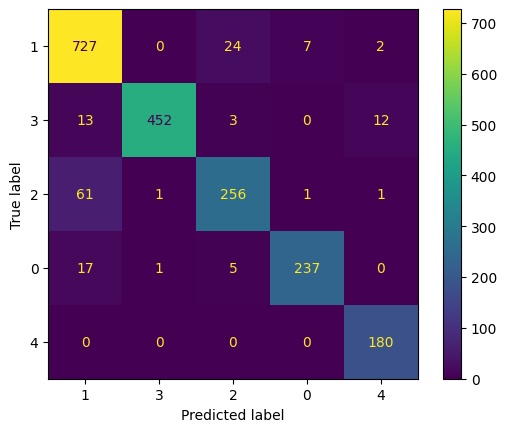

In [127]:
lab=[1,3,2,0,4]
cmd_rf=ConfusionMatrixDisplay(cm_rf,display_labels=lab)
cmd_rf.plot()

In [128]:
score_rf=accuracy_score(y_test,y_pred_rf)*100
score_rf

92.60000000000001

In [129]:
report_rf=classification_report(y_test,y_pred_rf)
print(report_rf)

              precision    recall  f1-score   support

           0       0.89      0.96      0.92       760
           1       1.00      0.94      0.97       480
           2       0.89      0.80      0.84       320
           3       0.97      0.91      0.94       260
           4       0.92      1.00      0.96       180

    accuracy                           0.93      2000
   macro avg       0.93      0.92      0.93      2000
weighted avg       0.93      0.93      0.93      2000



In [130]:
data={
    'model':['naive_bayes','KNN','LogisticRegression','svm','Decision_tree','Random_forest'],
    'score':[score_nb,score_knn,score_lr,score_svm,score_dt,score_rf]
}

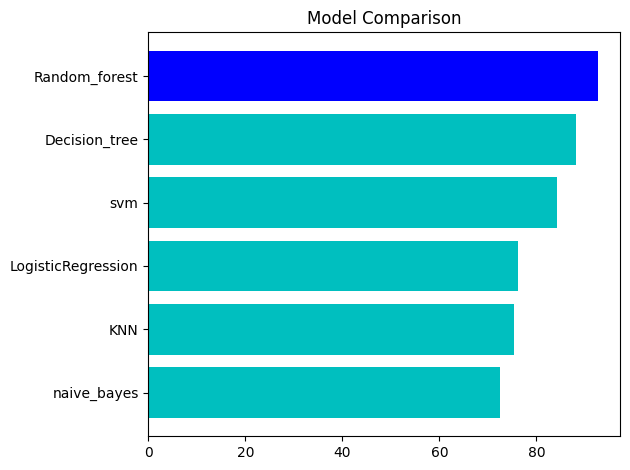

In [131]:
plt.barh(data['model'],data['score'],color=['c','c','c','c','c','b'])
plt.title('Model Comparison')
plt.tight_layout()

In [132]:
joblib.dump(rf, "anomaly_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']